Using device: cpu


100%|██████████| 170M/170M [01:15<00:00, 2.27MB/s]


Dataset loaded: 100 images
Epoch [1/1], Loss: 762.3708


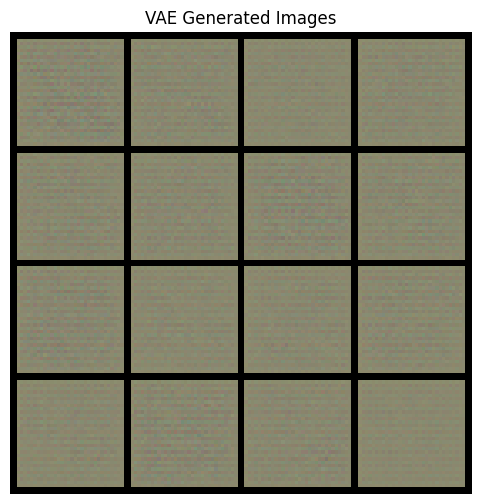

VAE training completed successfully.
Generated 16 new images.


In [3]:
# EXP 8: Variational Autoencoder (VAE) using CIFAR-10
# Fast CPU-friendly version

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid

# --------------------------------------------------
# 1. Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------------------------------
# 2. Load CIFAR-10 Dataset
# --------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Use only 100 images for fast execution
dataset = Subset(dataset, range(100))

loader = DataLoader(
    dataset,
    batch_size=20,
    shuffle=True
)

print("Dataset loaded:", len(dataset), "images")

# --------------------------------------------------
# 3. VAE Model
# --------------------------------------------------
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1),   # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, 2, 1),  # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 8 -> 4
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64 * 4 * 4, 16)
        self.fc_logvar = nn.Linear(64 * 4 * 4, 16)

        # Decoder
        self.fc_decode = nn.Linear(16, 64 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),  # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, 2, 1),   # 16 -> 32
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 64, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z)

        return output, mu, logvar


# Create model
model = VAE().to(device)

# --------------------------------------------------
# 4. Loss Function
# --------------------------------------------------
def vae_loss(reconstructed, original, mu, logvar):

    reconstruction_loss = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss


# --------------------------------------------------
# 5. Training
# --------------------------------------------------
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 1

for epoch in range(epochs):

    total_loss = 0

    for images, _ in loader:

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(images)

        loss = vae_loss(
            reconstructed,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {total_loss / len(dataset):.4f}"
    )

# --------------------------------------------------
# 6. Generate New Images
# --------------------------------------------------
model.eval()

with torch.no_grad():

    # Random latent vectors
    z = torch.randn(16, 16).to(device)

    generated_images = model.decode(z)

# Convert [-1,1] -> [0,1]
generated_images = (generated_images + 1) / 2

# --------------------------------------------------
# 7. Display Generated Images
# --------------------------------------------------
grid = make_grid(
    generated_images.cpu(),
    nrow=4
)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("VAE Generated Images")
plt.show()

print("VAE training completed successfully.")
print("Generated 16 new images.")